In [4]:
import os

import pandas as pd

# --- Data Ingestion & Sanitation ---

#  Load the dataset (Interpret '?' as missing values)
df = pd.read_csv('../data/raw/diabetic_data.csv', na_values='?', low_memory=False) #low_memory=False use to suppress dtype warning 

# Drop 'weight' column (Data Quality Limitation: >90% missing)
if 'weight' in df.columns:
    df.drop(columns=['weight'], inplace=True)
    print("Dropped 'weight' column due to excessive missing values.")

# Based on IDs_mapping.csv, IDs 11, 19, 20, 21 mean "Expired" (Died).
# Need to remove them because they cannot be readmitted.
expired_ids = [11, 19, 20, 21]
before_drop = df.shape[0] #count number of rows before dropping
df = df[~df['discharge_disposition_id'].isin(expired_ids)]
print(f"Removed {before_drop - df.shape[0]} patients who expired.")

# Remove exact duplicates if any exist
df = df.drop_duplicates()

if not os.path.exists('../data/processed'):
    os.makedirs('../data/processed')

#save the cleaned data for next phases
df.to_csv('../data/processed/diabetic_data_cleaned.csv', index=False)#saving cleaned data for next phases

print(f"Final Data Shape: {df.shape}")
print("Phase Complete. Data is clean.")

Dropped 'weight' column due to excessive missing values.
Removed 1652 patients who expired.
Final Data Shape: (100114, 49)
Phase Complete. Data is clean.


In [10]:
import requests
from bs4 import BeautifulSoup
import time


# --- Data Enrichment  ---

top_20_counts = df['diag_1'].value_counts().head(20) # Calculate frequency and identify top 20 most frequent diagnoses
top_codes = top_20_counts.index.tolist()
print(f"Top 20 Codes identified: {top_codes}")

print("\n---Web Scraping Execution ---")
scraped_data = {}

# Common headers to mimic a real browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

for code in top_codes:
    # Use the Search URL from the project spec
    url = f"http://icd9.chrisendres.com/index.php?action=search&srchtext={code}"
    
    try:
        response = requests.get(url, headers=headers, timeout=10)
        
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            
            found_text = "Description Not Found"
            
            # STRATEGY: Find the exact link that contains in code
            # The search result usually lists the code as a link (<a> tag) followed by the description
            # Example HTML: <a href="...">428</a>: Heart failure
            
            # 1. Find all links that contain the code text
            links = soup.find_all('a') # Get all <a> tags
            
            for link in links:
                if link.get_text().strip() == str(code):
            
                    # The description is usually in the parent tag or the next sibling text
                    parent_text = link.parent.get_text().strip() # Get the full text of the parent element
                    
                    # Clean the text (remove the code itself)
                    # Example: "428: Heart failure" -> "Heart failure"
                    found_text = parent_text.replace(str(code), "").strip(" :.-") # Remove code and extra characters
                    break
            
            # 2. Fallback: If link strategy fails, search raw text
            if found_text == "Description Not Found":
                page_text = soup.get_text() # Get all text from the page
               
                search_pattern = str(code) + " "# Look for code followed by space(code+" ")
                index = page_text.find(search_pattern)

                if index != -1:
                     # Grab the next 50 characters
                    chunk = page_text[index+len(search_pattern):index+80] # Grab next 80 chars after code
                    found_text = chunk.split('\n')[0].strip(" :.-")# Clean up to first newline or extra chars

            scraped_data[str(code)] = found_text# Store the result
            print(f"Scraped {code}: {found_text}")
            
        else:
            print(f"Failed to load URL for {code} (Status: {response.status_code})")
            scraped_data[str(code)] = "Lookup Failed"

    except Exception as e:
        print(f"Error for {code}: {e}")
        scraped_data[str(code)] = "Error"
        
    time.sleep(1) #delay between requests to be polite

print("\n---Integration ---")

def map_diagnosis(code):
    return scraped_data.get(str(code), "Other/Not in Top 20") # Map code to description or default

df['Primary_Diagnosis_Desc'] = df['diag_1'].apply(map_diagnosis) # Create new column with descriptions named 'Primary_Diagnosis_Desc'

# Verification
print("Integration Complete.")
print(df[['diag_1', 'Primary_Diagnosis_Desc']].head(10))

# Save the enriched data
df.to_csv('../data/processed/diabetic_data_enriched.csv', index=False)
print("Data saved to data/processed/diabetic_data_enriched.csv")

Top 20 Codes identified: ['428', '414', '786', '410', '486', '427', '491', '715', '682', '780', '434', '996', '276', '250.8', '599', '38', '584', 'V57', '250.6', '820']

---Web Scraping Execution ---
Scraped 428: Heart failure
Scraped 414: Other forms of chronic ischemic heart disease
Scraped 786: Symptoms involving respiratory system and other chest symptoms
Scraped 410: Acute myocardial infarction
Scraped 486: Pneumonia, organism unspecified
Scraped 427: Cardiac dysrhythmias
Scraped 491: Chronic bronchitis
Scraped 715: Osteoarthrosis and allied disorders
Scraped 682: Other cellulitis and abscess
Scraped 780: General symptoms
Scraped 434: Occlusion of cerebral arteries
Scraped 996: Complications peculiar to certain specified procedures
Scraped 276: Disorders of fluid, electrolyte, and acid-base balance
Scraped 250.8: Diabetes with other specified manifestations
Scraped 599: Other disorders of urethra and urinary tract
Scraped 38: Description Not Found
Scraped 584: Acute renal failure


Starting Exploratory Data Analysis...


/tmp/ipykernel_30368/1249507413.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, palette='viridis', order=['NO', '>30', '<30'])


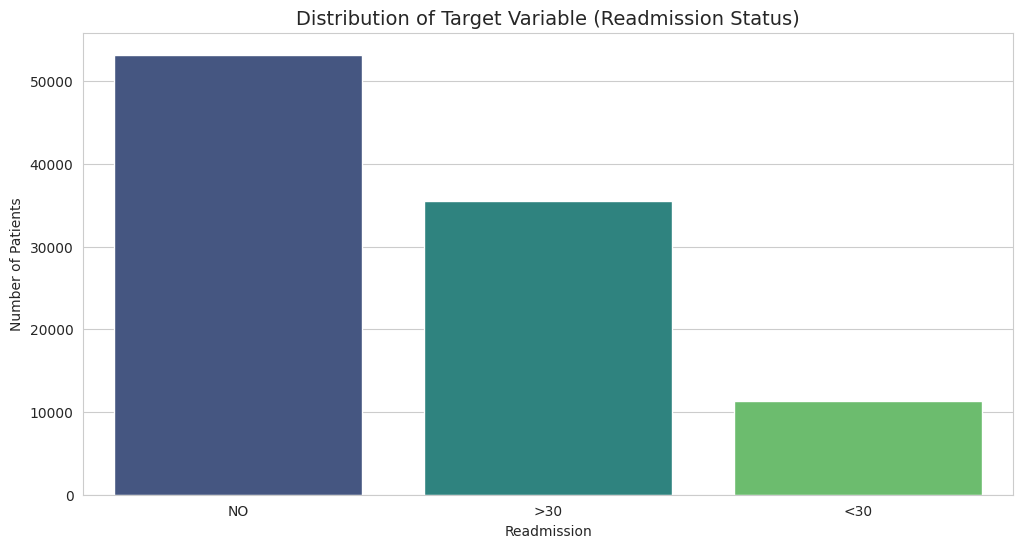

/tmp/ipykernel_30368/1249507413.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, palette='coolwarm',


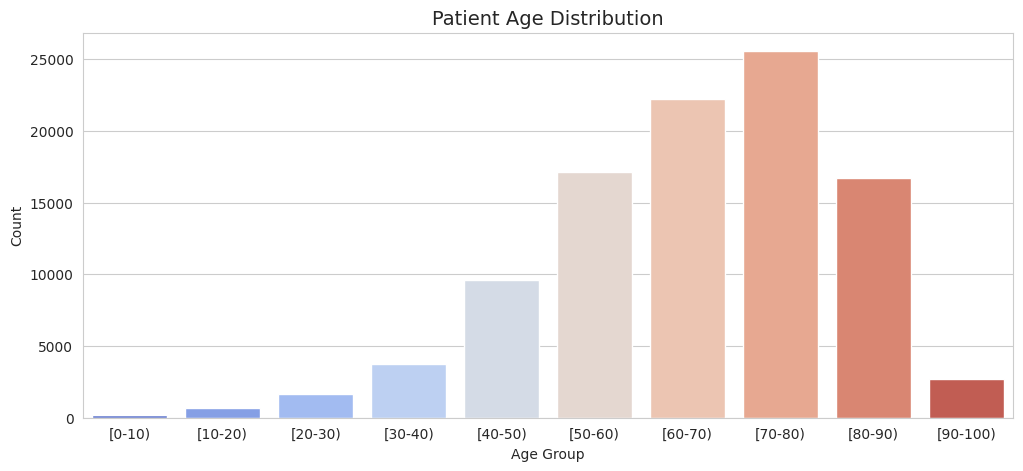

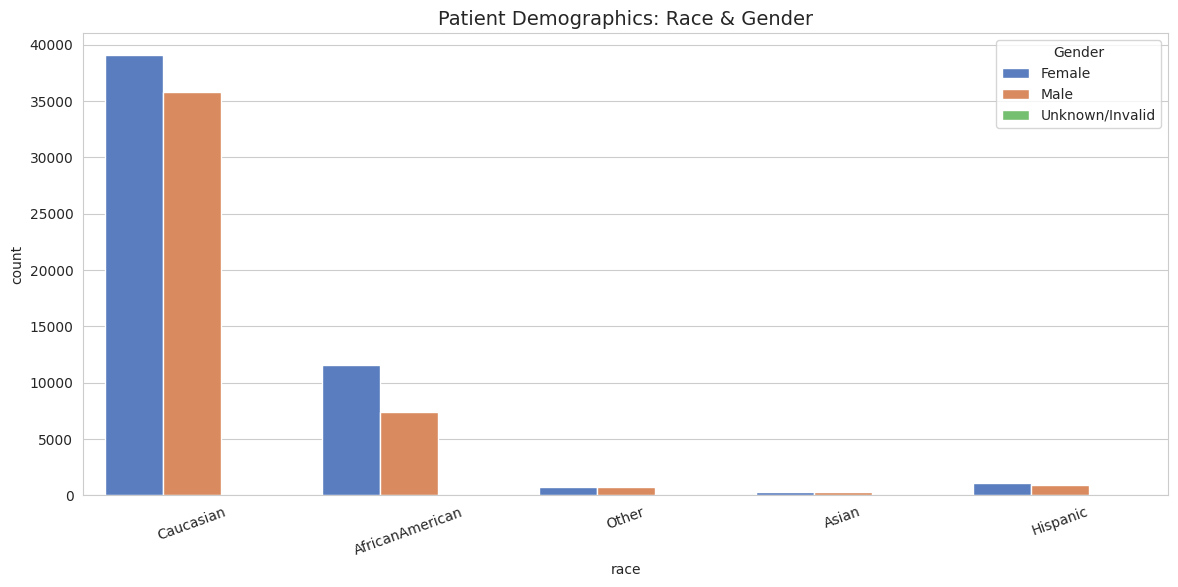

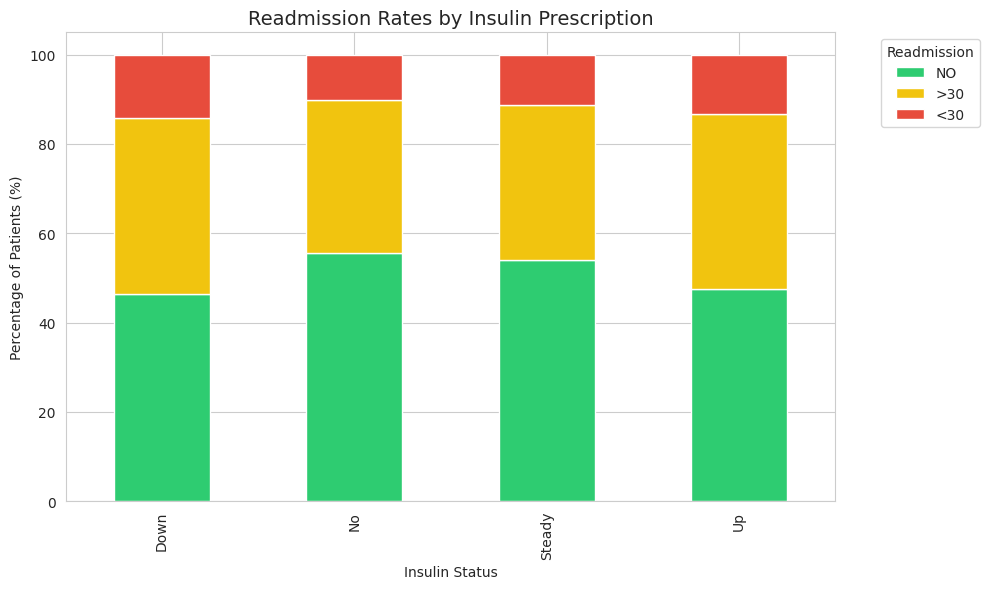

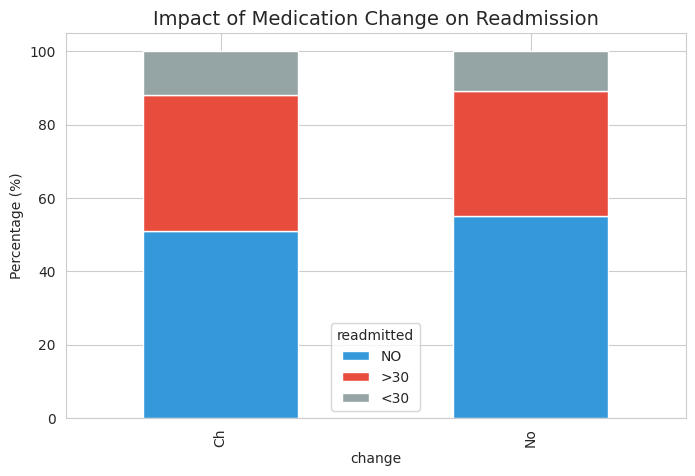

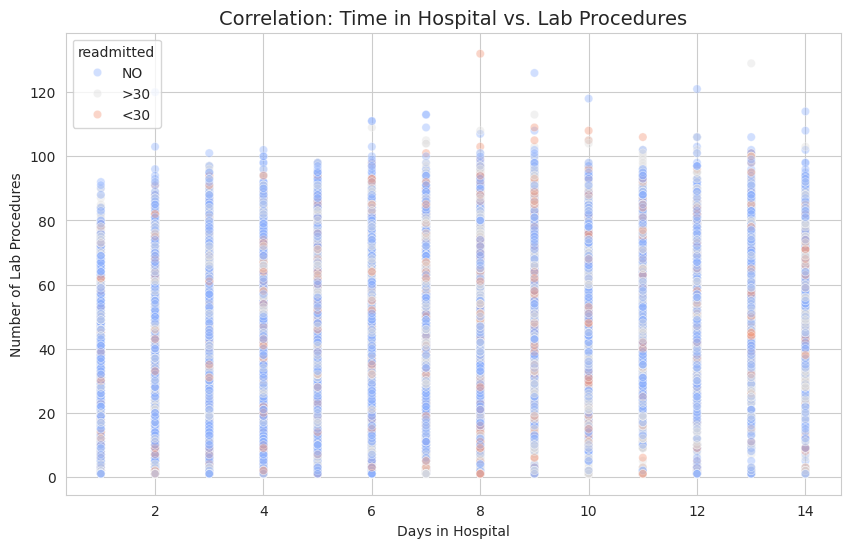

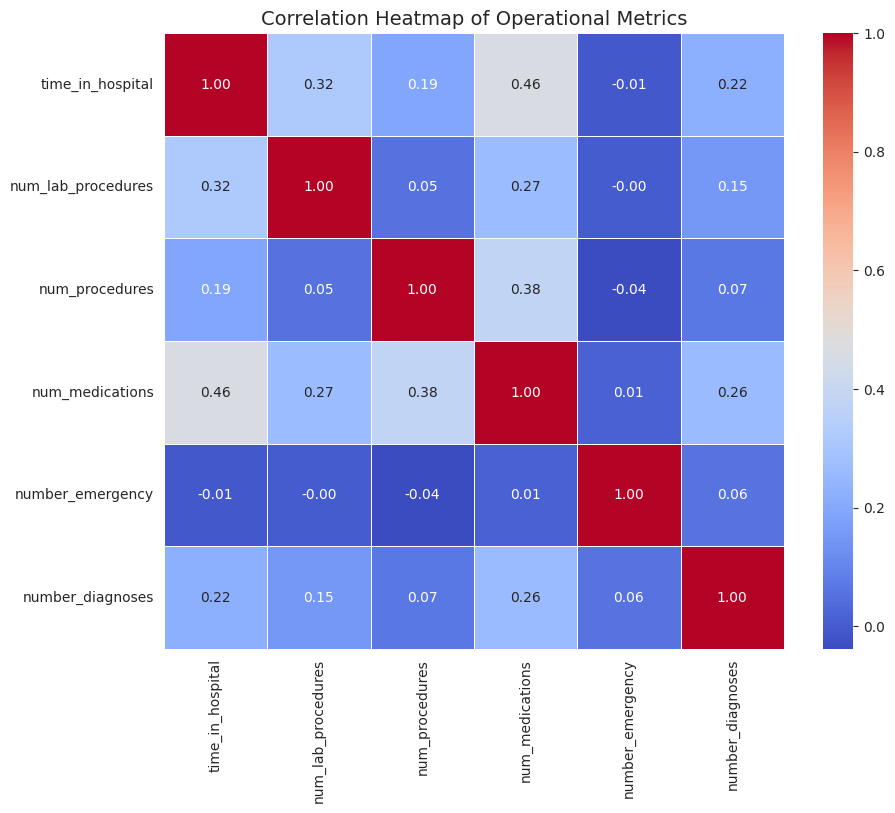

/tmp/ipykernel_30368/1249507413.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=df, order=['NO', '>30', '<30'], palette='Pastel1')


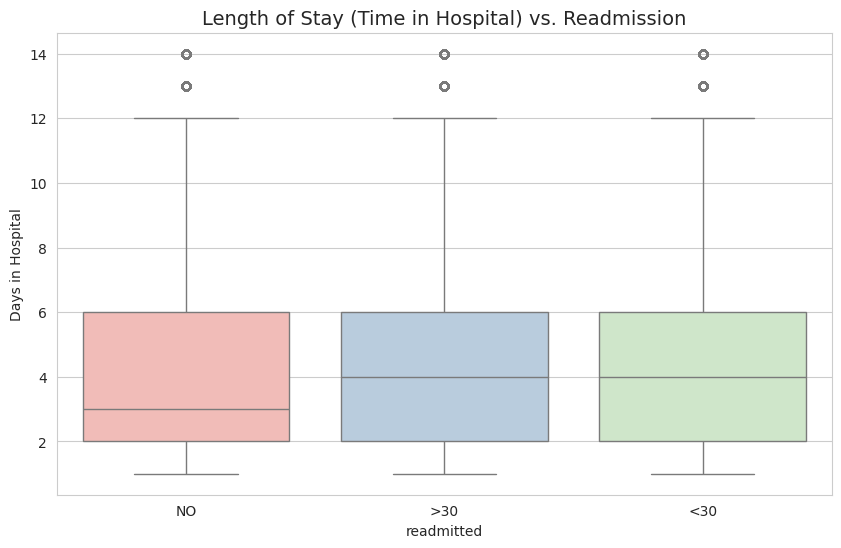

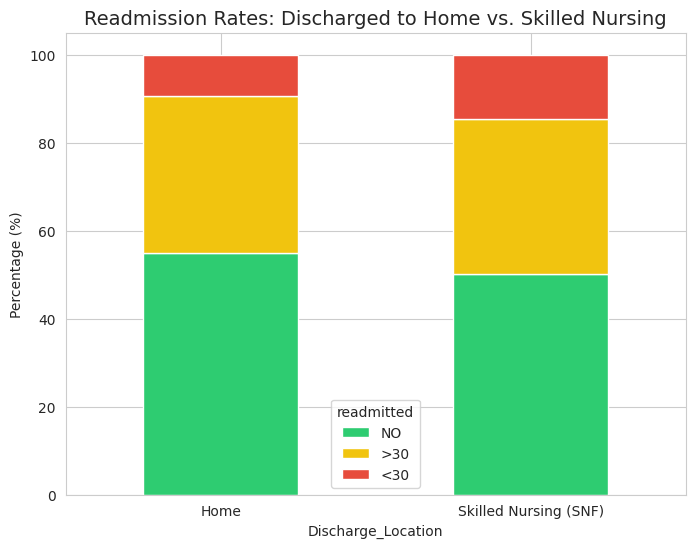

All charts saved to reports/figures/.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---Exploratory Data Analysis (EDA) ---
print("Starting Exploratory Data Analysis...")

# df = pd.read_csv('../data/processed/diabetic_data_enriched.csv')

if not os.path.exists('../reports'):
    os.makedirs('../reports/figures')

# Set professional plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- The Readmission Landscape (Target Variable) ---
#Generate a count plot for the readmitted variable
plt.figure()
sns.countplot(x='readmitted', data=df, palette='viridis', order=['NO', '>30', '<30'])
plt.title('Distribution of Target Variable (Readmission Status)', fontsize=14)
plt.xlabel('Readmission')
plt.ylabel('Number of Patients')


    
plt.savefig('../reports/figures/1_readmission_distribution.png')
plt.show()

# ---  Demographic Profiling ---
# Visualize distribution of age
plt.figure(figsize=(12, 5))
sns.countplot(x='age', data=df, palette='coolwarm', 
              order=['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)','[50-60)','[60-70)','[70-80)','[80-90)','[90-100)'])
plt.title('Patient Age Distribution', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.savefig('../reports/figures/2_age_distribution.png')
plt.show()

#Readmission by Race and Gender
#Visualize distribution of race and gender 
plt.figure(figsize=(14, 6))
sns.countplot(x='race', hue='gender', data=df, palette='muted')
plt.title('Patient Demographics: Race & Gender', fontsize=14)
plt.xticks(rotation=20)
plt.legend(title='Gender', loc='upper right')
plt.savefig('../reports/figures/3_demographics_race_gender.png')
plt.show()

# ---Medication Efficacy Analysis ---
# Compare readmission rates of patients on Insulin
# using normalized crosstab to show percentages (Rates) instead of raw counts
insulin_risk = pd.crosstab(df['insulin'], df['readmitted'], normalize='index') * 100
insulin_risk = insulin_risk[['NO', '>30', '<30']] # Reorder for clarity

ax = insulin_risk.plot(kind='bar', stacked=True, color=['#2ecc71', '#f1c40f', '#e74c3c'], figsize=(10,6))
plt.title('Readmission Rates by Insulin Prescription', fontsize=14)
plt.xlabel('Insulin Status')
plt.ylabel('Percentage of Patients (%)')
plt.legend(title='Readmission', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/figures/4_insulin_readmission_rate.png')
plt.show()

#Analyze the change column
#Visualize impact of medication change on readmission rates
change_risk = pd.crosstab(df['change'], df['readmitted'], normalize='index') * 100
change_risk = change_risk[['NO', '>30', '<30']]

ax = change_risk.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c', '#95a5a6'], figsize=(8,5))
plt.title('Impact of Medication Change on Readmission', fontsize=14)
plt.ylabel('Percentage (%)')
plt.savefig('../reports/figures/5_med_change_impact.png')
plt.show()

# ---Operational Metrics ---
#Visualize relationship between time_in_hospital and num_lab_procedures
plt.figure(figsize=(10, 6))
sns.scatterplot(x='time_in_hospital', y='num_lab_procedures', hue='readmitted', 
                data=df, alpha=0.4, palette='coolwarm')
plt.title('Correlation: Time in Hospital vs. Lab Procedures', fontsize=14)
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Lab Procedures')
plt.savefig('../reports/figures/6_hospital_vs_lab.png')
plt.show()

# Correlation Heatmap
# Select numerical columns of interest
corr_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
             'num_medications', 'number_emergency', 'number_diagnoses']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Operational Metrics', fontsize=14)
plt.savefig('../reports/figures/7_correlation_heatmap.png')
plt.show()

#Box plots of time_in_hospital grouped by readmitted status
plt.figure(figsize=(10, 6))
sns.boxplot(x='readmitted', y='time_in_hospital', data=df, order=['NO', '>30', '<30'], palette='Pastel1')
plt.title('Length of Stay (Time in Hospital) vs. Readmission', fontsize=14)
plt.ylabel('Days in Hospital')
plt.savefig('../reports/figures/8_los_boxplot.png')
plt.show()

# ---Discharge Disposition Analysis ---
# Compare "Skilled Nursing" vs "Home"
# Mapping specific IDs for clarity (Ref: IDs_mapping.csv)
subset_df = df[df['discharge_disposition_id'].isin([1, 3])].copy()
subset_df['Discharge_Location'] = subset_df['discharge_disposition_id'].map({1: 'Home', 3: 'Skilled Nursing (SNF)'})

discharge_risk = pd.crosstab(subset_df['Discharge_Location'], subset_df['readmitted'], normalize='index') * 100
discharge_risk = discharge_risk[['NO', '>30', '<30']]

discharge_risk.plot(kind='bar', stacked=True, color=['#2ecc71', '#f1c40f', '#e74c3c'], figsize=(8,6))
plt.title('Readmission Rates: Discharged to Home vs. Skilled Nursing', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.savefig('../reports/figures/9_discharge_location_risk.png')
plt.show()

print("All charts saved to reports/figures/.")